In [2]:
import csv
import numpy as np

age=[]
fare=[]
survived=[]

with open('/content/Titanic-Dataset.csv','r') as file:
  data = csv.DictReader(file)
  for row in data:
    if row['Age'] and row['Fare']:
      age.append(float(row['Age']))
      fare.append(float(row['Fare']))
      survived.append(float(row['Survived']))

age_arr = np.array(age)
fare_arr = np.array(fare)
survived_arr = np.array(survived)

mean_age = np.mean(age_arr)
median_age = np.median(age_arr)
std_age = np.std(age_arr)

print("Mean Age:", round(mean_age,2))
print("Median Age:", median_age)
print("Standard Deviation of Age:", round(std_age,2))

print("-"*100)

top_10 = np.percentile(fare_arr,90)
bot_10 = np.percentile(fare_arr,10)

print("Top 10% of Fare:", round(top_10,2))
print("Bottom 10% of Fare:", round(bot_10,2))

print("-"*100)


print("No. of child Survived:", np.sum(survived_arr[age_arr<15]))
print("No. of Adult Survived:", np.sum(survived_arr[(age_arr > 15) & (age_arr < 60)]))
print("No. of Oldage Survived:",np.sum(survived_arr[age_arr>60]))

print("-"*100)

print("Mean Survived Age<15 :", np.mean(survived_arr[age_arr<15]))
print("Mean Survived Age 15to60:", np.mean(survived_arr[(age_arr > 15) & (age_arr < 60)]))
print("Mean Survived Age>60:", np.mean(survived_arr[age_arr>60]))



Mean Age: 29.7
Median Age: 28.0
Standard Deviation of Age: 14.52
----------------------------------------------------------------------------------------------------
Top 10% of Fare: 79.52
Bottom 10% of Fare: 7.75
----------------------------------------------------------------------------------------------------
No. of child Survived: 45.0
No. of Adult Survived: 234.0
No. of Oldage Survived: 5.0
----------------------------------------------------------------------------------------------------
Mean Survived Age<15 : 0.5769230769230769
Mean Survived Age 15to60: 0.3867768595041322
Mean Survived Age>60: 0.22727272727272727


(array([27.,  9.,  4., 15., 27., 36., 30., 35., 35., 17., 12., 12., 14.,
        7.,  5.,  4.,  0.,  0.,  0.,  1.]), array([ 0.42 ,  4.399,  8.378, 12.357, 16.336, 20.315, 24.294, 28.273,
       32.252, 36.231, 40.21 , 44.189, 48.168, 52.147, 56.126, 60.105,
       64.084, 68.063, 72.042, 76.021, 80.   ]), <BarContainer object of 20 artists>)


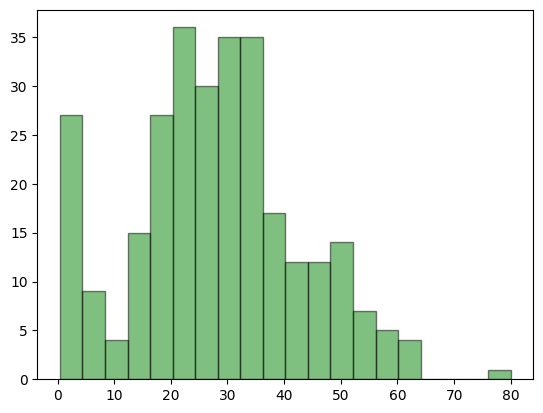

In [3]:
import matplotlib.pyplot as plt
#plot survived persons vs age
print(plt.hist(age_arr[survived_arr == 1], bins=20, alpha=0.5, label='Survived', color='green', edgecolor='black'))

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/Titanic-Dataset.csv")
print(df['Age'].tail())
print("-"*100)
# Fill Age using the median of their specific Passenger Class
df['Age'] = df['Age'].fillna(df.groupby('Pclass')['Age'].transform('median'))
print(df['Age'].tail())
print("-"*100)
print(df['Embarked'].tail())
print("-"*100)
# Fill Embarked with the Mode (most common value)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
# [0] tells Hey Pandas, find the most frequent values, grab the very first one at index 0, and give me just that single value.
print(df['Embarked'].tail())

886    27.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: Age, dtype: float64
----------------------------------------------------------------------------------------------------
886    27.0
887    19.0
888    24.0
889    26.0
890    32.0
Name: Age, dtype: float64
----------------------------------------------------------------------------------------------------
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, dtype: object
----------------------------------------------------------------------------------------------------
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, dtype: object


In [5]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
df['FarePerPerson'] = df['Fare'] / df['FamilySize']

print(df['FamilySize'].head())
print("-"*100)
print(df['IsAlone'].head())
print("-"*100)
print(df['FarePerPerson'].head())

0    2
1    2
2    1
3    2
4    1
Name: FamilySize, dtype: int64
----------------------------------------------------------------------------------------------------
0    0
1    0
2    1
3    0
4    1
Name: IsAlone, dtype: int64
----------------------------------------------------------------------------------------------------
0     3.62500
1    35.64165
2     7.92500
3    26.55000
4     8.05000
Name: FarePerPerson, dtype: float64


In [6]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 16, 60, 100],
    labels=['Child', 'Adult', 'Senior']
)
print(df['AgeGroup'].head())
print("-"*100)
df['FareGroup'] = pd.qcut(
    df['Fare'],
    q=3,
    labels=['Low', 'Medium', 'High']
)
print(df['FareGroup'].head())




0    Adult
1    Adult
2    Adult
3    Adult
4    Adult
Name: AgeGroup, dtype: category
Categories (3, object): ['Child' < 'Adult' < 'Senior']
----------------------------------------------------------------------------------------------------
0     Low
1    High
2     Low
3    High
4     Low
Name: FareGroup, dtype: category
Categories (3, object): ['Low' < 'Medium' < 'High']


In [7]:
pivot_gender_class = pd.pivot_table(
    df,
    values='Survived',
    index='Sex',
    columns='Pclass',
    aggfunc='mean'
)
print(pivot_gender_class)
print("-"*100)
pivot_fare_embarked = pd.pivot_table(
    df,
    values='Survived',
    index='FareGroup',
    columns='Embarked',
    aggfunc='mean'
)
print(pivot_fare_embarked)


Pclass         1         2         3
Sex                                 
female  0.968085  0.921053  0.500000
male    0.368852  0.157407  0.135447
----------------------------------------------------------------------------------------------------
Embarked          C         Q         S
FareGroup                              
Low        0.250000  0.388889  0.142202
Medium     0.538462  0.500000  0.373391
High       0.677419  0.142857  0.517949


/tmp/ipykernel_1553/2875070594.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_fare_embarked = pd.pivot_table(


In [8]:
num_df = df.select_dtypes(include=np.number)
corr_matrix = num_df.corr()
print(corr_matrix)


               PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId       1.000000 -0.005007 -0.035144  0.035840 -0.057527 -0.001652   
Survived         -0.005007  1.000000 -0.338481 -0.047255 -0.035322  0.081629   
Pclass           -0.035144 -0.338481  1.000000 -0.408487  0.083081  0.018443   
Age               0.035840 -0.047255 -0.408487  1.000000 -0.243526 -0.171095   
SibSp            -0.057527 -0.035322  0.083081 -0.243526  1.000000  0.414838   
Parch            -0.001652  0.081629  0.018443 -0.171095  0.414838  1.000000   
Fare              0.012658  0.257307 -0.549500  0.123784  0.159651  0.216225   
FamilySize       -0.040143  0.016639  0.065997 -0.251918  0.890712  0.783111   
IsAlone           0.057462 -0.203367  0.135207  0.165356 -0.584471 -0.583398   
FarePerPerson     0.026303  0.221600 -0.485079  0.175111 -0.094682 -0.068978   

                   Fare  FamilySize   IsAlone  FarePerPerson  
PassengerId    0.012658   -0.040143  0.057462       0.02

In [9]:
corr_with_survival = corr_matrix['Survived'].abs().sort_values(ascending=False)
top5 = corr_with_survival[1:6]
print(top5)

Pclass           0.338481
Fare             0.257307
FarePerPerson    0.221600
IsAlone          0.203367
Parch            0.081629
Name: Survived, dtype: float64


In [10]:
df.groupby(['Sex', 'Pclass'])['Survived'].mean()

Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64

In [24]:
import pandas as pd
import numpy as np

# Step 1: Reload fresh copy of the dataset
df = pd.read_csv("/content/Titanic-Dataset.csv")

# Step 2: Fill missing values
df["Age"]      = df.groupby("Pclass")["Age"].transform(lambda x: x.fillna(x.median()))
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["Fare"]     = df["Fare"].fillna(df["Fare"].median())

# Step 3: Feature engineering
df["FamilySize"]    = df["SibSp"] + df["Parch"] + 1
df["IsAlone"]       = (df["FamilySize"] == 1).astype(int)
df["FarePerPerson"] = df["Fare"] / df["FamilySize"]

# Step 4: Bins — use -1 as lower bound to catch 0 values
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[-1, 15, 60, 200],
    labels=["Child", "Adult", "Senior"]
)

df["FareGroup"] = pd.cut(
    df["Fare"],
    bins=[-1, 15, 50, 600],
    labels=["Low", "Medium", "High"]
)

# Step 5: Encode to numbers
df["Sex_num"]       = (df["Sex"] == "female").astype(int)
df["AgeGroup_num"]  = df["AgeGroup"].map({"Child": 2, "Adult": 1, "Senior": 0})
df["FareGroup_num"] = df["FareGroup"].map({"Low": 0, "Medium": 1, "High": 2})

# Step 6: Verify — should all be 0
print("NaN check after full rebuild:")
check_cols = ["Sex_num", "Pclass", "AgeGroup_num", "FareGroup_num", "FamilySize", "Survived"]
print(df[check_cols].isnull().sum())
print(f"\nTotal rows: {len(df)}")


NaN check after full rebuild:
Sex_num          0
Pclass           0
AgeGroup_num     0
FareGroup_num    0
FamilySize       0
Survived         0
dtype: int64

Total rows: 891


In [26]:
features = ["Sex_num", "Pclass", "AgeGroup_num", "FareGroup_num", "FamilySize"]
target   = "Survived"

df_clean = df[features + [target]].dropna().copy()
print(f"Rows after dropna: {len(df_clean)}")

X = df_clean[features].values.astype(float)
y = df_clean[target].values.astype(float)

X_min  = X.min(axis=0)
X_max  = X.max(axis=0)
X_norm = (X - X_min) / (X_max - X_min + 1e-8)

print(f"Feature matrix shape : {X_norm.shape}")
print(f"Target vector shape  : {y.shape}")

Rows after dropna: 891
Feature matrix shape : (891, 5)
Target vector shape  : (891,)


In [28]:
# Weights based on correlation strength from Part 2
# Sex has highest correlation, then Pclass, AgeGroup, FareGroup, FamilySize
weights = np.array([0.40, 0.25, 0.15, 0.12, 0.08])

# Compute survival score (0–1)
# Pclass is inverse (lower class number = better), so invert it
X_weighted = X_norm.copy()
X_weighted[:, 1] = 1 - X_weighted[:, 1]  # Invert Pclass

survival_scores = X_weighted @ weights  # Matrix multiplication

# Normalize scores to 0–1 range
survival_scores = (survival_scores - survival_scores.min()) / (
    survival_scores.max() - survival_scores.min()
)

print(f"Survival score range: {survival_scores.min():.3f} to {survival_scores.max():.3f}")
print(f"Mean score          : {survival_scores.mean():.3f}")
print(f"\nSample scores (first 10):")
for i in range(10):
    print(f"  Passenger {i+1}: score={survival_scores[i]:.3f}  actual={'Survived' if y[i]==1 else 'Died'}")

Survival score range: 0.000 to 1.000
Mean score          : 0.376

Sample scores (first 10):
  Passenger 1: score=0.088  actual=Died
  Passenger 2: score=0.904  actual=Survived
  Passenger 3: score=0.503  actual=Survived
  Passenger 4: score=0.904  actual=Survived
  Passenger 5: score=0.079  actual=Died
  Passenger 6: score=0.079  actual=Died
  Passenger 7: score=0.471  actual=Died
  Passenger 8: score=0.256  actual=Died
  Passenger 9: score=0.520  actual=Survived
  Passenger 10: score=0.787  actual=Survived


In [30]:
# Classify using threshold = 0.5
predictions = (survival_scores >= 0.5).astype(int)

# Confusion matrix manually using NumPy
TP = np.sum((predictions == 1) & (y == 1))
TN = np.sum((predictions == 0) & (y == 0))
FP = np.sum((predictions == 1) & (y == 0))
FN = np.sum((predictions == 0) & (y == 1))

accuracy  = (TP + TN) / len(y) * 100
precision = TP / (TP + FP) * 100 if (TP + FP) > 0 else 0
recall    = TP / (TP + FN) * 100 if (TP + FN) > 0 else 0
random_accuracy = 50.0  # Random guessing baseline

print("=" * 50)
print("  MODEL PERFORMANCE")
print("=" * 50)
print(f"\n  Confusion Matrix:")
print(f"               Predicted")
print(f"             Died  Survived")
print(f"  Actual Died   {TN:>4}    {FP:>4}")
print(f"  Actual Surv   {FN:>4}    {TP:>4}")
print()
print(f"  Accuracy  : {accuracy:.1f}%")
print(f"  Precision : {precision:.1f}%")
print(f"  Recall    : {recall:.1f}%")
print()
print(f"  Random guessing baseline : {random_accuracy:.1f}%")
print(f"  Our model improvement    : +{accuracy - random_accuracy:.1f}%")
print()
if accuracy > random_accuracy + 15:
    print("Model significantly outperforms random guessing.")
else:
    print("Model only marginally better than random guessing.")
print("=" * 50)

  MODEL PERFORMANCE

  Confusion Matrix:
               Predicted
             Died  Survived
  Actual Died    467      82
  Actual Surv    107     235

  Accuracy  : 78.8%
  Precision : 74.1%
  Recall    : 68.7%

  Random guessing baseline : 50.0%
  Our model improvement    : +28.8%

Model significantly outperforms random guessing.


In [31]:
# Load raw data as NumPy arrays
df_bonus = pd.read_csv("/content/Titanic-Dataset.csv")

survived = df_bonus["Survived"].values
pclass   = df_bonus["Pclass"].values
sex      = (df_bonus["Sex"] == "female").astype(int).values

# Survival by Class — fully vectorized, no loops
print("=" * 40)
print("  SURVIVAL BY CLASS (Vectorized)")
print("=" * 40)
for cls in [1, 2, 3]:
    mask = pclass == cls
    rate = np.mean(survived[mask]) * 100
    print(f"  Class {cls}: {rate:.1f}%  (n={mask.sum()})")

# Survival by Gender — fully vectorized
print("\n" + "=" * 40)
print("  SURVIVAL BY GENDER (Vectorized)")
print("=" * 40)
for label, mask in [("Female", sex == 1), ("Male", sex == 0)]:
    rate = np.mean(survived[mask]) * 100
    print(f"  {label}: {rate:.1f}%  (n={mask.sum()})")

  SURVIVAL BY CLASS (Vectorized)
  Class 1: 63.0%  (n=216)
  Class 2: 47.3%  (n=184)
  Class 3: 24.2%  (n=491)

  SURVIVAL BY GENDER (Vectorized)
  Female: 74.2%  (n=314)
  Male: 18.9%  (n=577)


In [32]:
def predict_survival(passenger_dict):
    """
    Predict survival probability for a single passenger.

    Args:
        passenger_dict (dict): Keys — Sex, Pclass, Age, Fare, FamilySize

    Returns:
        dict: score (0–1), prediction (Survived/Did not survive), confidence
    """
    # Extract and encode features
    sex_num    = 1.0 if passenger_dict.get("Sex", "male").lower() == "female" else 0.0
    pclass     = float(passenger_dict.get("Pclass", 3))
    age        = float(passenger_dict.get("Age", 30))
    fare       = float(passenger_dict.get("Fare", 15))
    family_size= float(passenger_dict.get("FamilySize", 1))

    # AgeGroup encoding
    if age < 15:
        age_group = 2.0  # Child
    elif age <= 60:
        age_group = 1.0  # Adult
    else:
        age_group = 0.0  # Senior

    # FareGroup encoding
    if fare < 15:
        fare_group = 0.0
    elif fare < 50:
        fare_group = 1.0
    else:
        fare_group = 2.0

    # Normalize using known min/max from training data
    features = np.array([sex_num, pclass, age_group, fare_group, family_size])
    mins     = np.array([0, 1, 0, 0, 1])
    maxs     = np.array([1, 3, 2, 2, 11])
    norm     = (features - mins) / (maxs - mins + 1e-8)

    # Invert Pclass (lower class number = better survival)
    norm[1] = 1 - norm[1]

    # Apply weights
    weights = np.array([0.40, 0.25, 0.15, 0.12, 0.08])
    score = float(np.dot(norm, weights))

    # Normalize to 0–1
    score = max(0.0, min(1.0, score))

    prediction = "Survived" if score >= 0.5 else "Did not survive"
    confidence = score if score >= 0.5 else 1 - score

    return {
        "score"     : round(score, 3),
        "prediction": prediction,
        "confidence": f"{confidence*100:.1f}%"
    }


# --- Test cases ---
print("=" * 55)
print("  predict_survival() — Test Cases")
print("=" * 55)

test_passengers = [
    {"Sex": "female", "Pclass": 1, "Age": 28, "Fare": 100, "FamilySize": 1},
    {"Sex": "male",   "Pclass": 3, "Age": 35, "Fare": 8,   "FamilySize": 1},
    {"Sex": "female", "Pclass": 3, "Age": 8,  "Fare": 15,  "FamilySize": 4},
    {"Sex": "male",   "Pclass": 1, "Age": 50, "Fare": 80,  "FamilySize": 2},
    {"Sex": "female", "Pclass": 2, "Age": 25, "Fare": 25,  "FamilySize": 1},
]

for p in test_passengers:
    result = predict_survival(p)
    print(f"\n  Input      : {p['Sex']}, Class {p['Pclass']}, Age {p['Age']}, Fare £{p['Fare']}")
    print(f"  Score      : {result['score']}")
    print(f"  Prediction : {result['prediction']}")
    print(f"  Confidence : {result['confidence']}")

  predict_survival() — Test Cases

  Input      : female, Class 1, Age 28, Fare £100
  Score      : 0.845
  Prediction : Survived
  Confidence : 84.5%

  Input      : male, Class 3, Age 35, Fare £8
  Score      : 0.075
  Prediction : Did not survive
  Confidence : 92.5%

  Input      : female, Class 3, Age 8, Fare £15
  Score      : 0.634
  Prediction : Survived
  Confidence : 63.4%

  Input      : male, Class 1, Age 50, Fare £80
  Score      : 0.453
  Prediction : Did not survive
  Confidence : 54.7%

  Input      : female, Class 2, Age 25, Fare £25
  Score      : 0.66
  Prediction : Survived
  Confidence : 66.0%
